In [4]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/aditio2311/hackathon/calendar.csv
/kaggle/input/datasets/aditio2311/hackathon/sample_submission.csv
/kaggle/input/datasets/aditio2311/hackathon/sell_prices.csv
/kaggle/input/datasets/aditio2311/hackathon/sales_train_validation.csv
/kaggle/input/datasets/aditio2311/hackathon/sales_train_evaluation.csv


In [5]:
import os

for dirname, _, filenames in os.walk('/kaggle/input'):
    print(dirname)
    for filename in filenames[:5]:
        print("  ", filename)
    

/kaggle/input
/kaggle/input/datasets
/kaggle/input/datasets/aditio2311
/kaggle/input/datasets/aditio2311/hackathon
   calendar.csv
   sample_submission.csv
   sell_prices.csv
   sales_train_validation.csv
   sales_train_evaluation.csv


In [6]:
import pandas as pd

sales = pd.read_csv('/kaggle/input/datasets/aditio2311/hackathon/sales_train_validation.csv')
calendar = pd.read_csv('/kaggle/input/datasets/aditio2311/hackathon/calendar.csv')
prices = pd.read_csv('/kaggle/input/datasets/aditio2311/hackathon/sell_prices.csv')

print(sales.shape)
print(calendar.shape)
print(prices.shape)

(30490, 1919)
(1969, 14)
(6841121, 4)


In [7]:
sales.head()

,id,item_id,dept_id,cat_id,store_id,state_id,d_1,d_2,d_3,d_4,...,d_1904,d_1905,d_1906,d_1907,d_1908,d_1909,d_1910,d_1911,d_1912,d_1913
0,HOBBIES_1_001_CA_1_validation,HOBBIES_1_001,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,...,1,3,0,1,1,1,3,0,1,1
1,HOBBIES_1_002_CA_1_validation,HOBBIES_1_002,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,...,0,0,0,0,0,1,0,0,0,0
2,HOBBIES_1_003_CA_1_validation,HOBBIES_1_003,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,...,2,1,2,1,1,1,0,1,1,1
3,HOBBIES_1_004_CA_1_validation,HOBBIES_1_004,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,...,1,0,5,4,1,0,1,3,7,2
4,HOBBIES_1_005_CA_1_validation,HOBBIES_1_005,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,...,2,1,1,0,1,1,2,2,2,4


In [8]:
sales.columns[:15]

Index(['id', 'item_id', 'dept_id', 'cat_id', 'store_id', 'state_id', 'd_1',
       'd_2', 'd_3', 'd_4', 'd_5', 'd_6', 'd_7', 'd_8', 'd_9'],
      dtype='object')

In [9]:
# Select a small subset first (faster for experimentation)

id_cols = ['id', 'item_id', 'dept_id', 'cat_id', 'store_id', 'state_id']

sales_long = sales.melt(
    id_vars=id_cols,
    var_name='d',
    value_name='sales'
)

print(sales_long.shape)
sales_long.head()

(58327370, 8)


,id,item_id,dept_id,cat_id,store_id,state_id,d,sales
0,HOBBIES_1_001_CA_1_validation,HOBBIES_1_001,HOBBIES_1,HOBBIES,CA_1,CA,d_1,0
1,HOBBIES_1_002_CA_1_validation,HOBBIES_1_002,HOBBIES_1,HOBBIES,CA_1,CA,d_1,0
2,HOBBIES_1_003_CA_1_validation,HOBBIES_1_003,HOBBIES_1,HOBBIES,CA_1,CA,d_1,0
3,HOBBIES_1_004_CA_1_validation,HOBBIES_1_004,HOBBIES_1,HOBBIES,CA_1,CA,d_1,0
4,HOBBIES_1_005_CA_1_validation,HOBBIES_1_005,HOBBIES_1,HOBBIES,CA_1,CA,d_1,0


In [10]:
sales_long.head()

,id,item_id,dept_id,cat_id,store_id,state_id,d,sales
0,HOBBIES_1_001_CA_1_validation,HOBBIES_1_001,HOBBIES_1,HOBBIES,CA_1,CA,d_1,0
1,HOBBIES_1_002_CA_1_validation,HOBBIES_1_002,HOBBIES_1,HOBBIES,CA_1,CA,d_1,0
2,HOBBIES_1_003_CA_1_validation,HOBBIES_1_003,HOBBIES_1,HOBBIES,CA_1,CA,d_1,0
3,HOBBIES_1_004_CA_1_validation,HOBBIES_1_004,HOBBIES_1,HOBBIES,CA_1,CA,d_1,0
4,HOBBIES_1_005_CA_1_validation,HOBBIES_1_005,HOBBIES_1,HOBBIES,CA_1,CA,d_1,0


In [11]:
sales_long.shape

(58327370, 8)

In [12]:
sales_long = sales_long.merge(
    calendar,
    on='d',
    how='left'
)

print(sales_long.shape)
sales_long.head()

(58327370, 21)


,id,item_id,dept_id,cat_id,store_id,state_id,d,sales,date,wm_yr_wk,...,wday,month,year,event_name_1,event_type_1,event_name_2,event_type_2,snap_CA,snap_TX,snap_WI
0,HOBBIES_1_001_CA_1_validation,HOBBIES_1_001,HOBBIES_1,HOBBIES,CA_1,CA,d_1,0,2011-01-29,11101,...,1,1,2011,NaN,NaN,NaN,NaN,0,0,0
1,HOBBIES_1_002_CA_1_validation,HOBBIES_1_002,HOBBIES_1,HOBBIES,CA_1,CA,d_1,0,2011-01-29,11101,...,1,1,2011,NaN,NaN,NaN,NaN,0,0,0
2,HOBBIES_1_003_CA_1_validation,HOBBIES_1_003,HOBBIES_1,HOBBIES,CA_1,CA,d_1,0,2011-01-29,11101,...,1,1,2011,NaN,NaN,NaN,NaN,0,0,0
3,HOBBIES_1_004_CA_1_validation,HOBBIES_1_004,HOBBIES_1,HOBBIES,CA_1,CA,d_1,0,2011-01-29,11101,...,1,1,2011,NaN,NaN,NaN,NaN,0,0,0
4,HOBBIES_1_005_CA_1_validation,HOBBIES_1_005,HOBBIES_1,HOBBIES,CA_1,CA,d_1,0,2011-01-29,11101,...,1,1,2011,NaN,NaN,NaN,NaN,0,0,0


In [13]:
sales_long[['d', 'date']].head()

,d,date
0,d_1,2011-01-29
1,d_1,2011-01-29
2,d_1,2011-01-29
3,d_1,2011-01-29
4,d_1,2011-01-29


In [14]:
sales_long = sales_long.sort_values(['id', 'date'])

sales_long['lag_7'] = sales_long.groupby('id')['sales'].shift(7)
sales_long['lag_28'] = sales_long.groupby('id')['sales'].shift(28)

In [15]:
sales_long['rolling_mean_7'] = (
    sales_long.groupby('id')['sales']
    .transform(lambda x: x.shift(1).rolling(7).mean())
)

sales_long['rolling_mean_28'] = (
    sales_long.groupby('id')['sales']
    .transform(lambda x: x.shift(1).rolling(28).mean())
)

In [16]:
sales_long['date'] = pd.to_datetime(sales_long['date'])

sales_long['dayofweek'] = sales_long['date'].dt.dayofweek
sales_long['month'] = sales_long['date'].dt.month
sales_long['year'] = sales_long['date'].dt.year

In [17]:
import pandas as pd

sales = pd.read_csv('/kaggle/input/datasets/aditio2311/hackathon/sales_train_validation.csv')
calendar = pd.read_csv('/kaggle/input/datasets/aditio2311/hackathon/calendar.csv')
prices = pd.read_csv('/kaggle/input/datasets/aditio2311/hackathon/sell_prices.csv')

In [18]:
sales_small = sales.head(100).copy()

print(sales_small.shape)

(100, 1919)


In [19]:
id_cols = [
    'id',
    'item_id',
    'dept_id',
    'cat_id',
    'store_id',
    'state_id'
]

sales_long = sales_small.melt(
    id_vars=id_cols,
    var_name='d',
    value_name='sales'
)

print(sales_long.shape)

(191300, 8)


In [20]:
sales_long = sales_long.merge(
    calendar,
    on='d',
    how='left'
)

In [21]:
sales_long['date'] = pd.to_datetime(sales_long['date'])

sales_long['dayofweek'] = sales_long['date'].dt.dayofweek
sales_long['month'] = sales_long['date'].dt.month
sales_long['year'] = sales_long['date'].dt.year

In [22]:
sales_long = sales_long.sort_values(['id', 'date'])

sales_long['lag_7'] = sales_long.groupby('id')['sales'].shift(7)

sales_long['lag_28'] = sales_long.groupby('id')['sales'].shift(28)

In [23]:
sales_long['rolling_mean_7'] = (
    sales_long.groupby('id')['sales']
    .transform(lambda x: x.shift(1).rolling(7).mean())
)

sales_long['rolling_mean_28'] = (
    sales_long.groupby('id')['sales']
    .transform(lambda x: x.shift(1).rolling(28).mean())
)

In [24]:
sales_long = sales_long.dropna()

print(sales_long.shape)

(400, 26)


In [25]:
features = [
    'lag_7',
    'lag_28',
    'rolling_mean_7',
    'rolling_mean_28',
    'dayofweek',
    'month',
    'year'
]

target = 'sales'

In [26]:
from sklearn.model_selection import train_test_split

X = sales_long[features]
y = sales_long[target]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print(X_train.shape)
print(X_test.shape)

(320, 7)
(80, 7)


In [27]:
!pip install lightgbm -q

In [28]:
from lightgbm import LGBMRegressor

model = LGBMRegressor(
    n_estimators=100,
    learning_rate=0.05,
    num_leaves=31,
    random_state=42
)

model.fit(X_train, y_train)

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.003478 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 103
[LightGBM] [Info] Number of data points in the train set: 320, number of used features: 6
[LightGBM] [Info] Start training from score 1.128125
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -in

LGBMRegressor(learning_rate=0.05, random_state=42)

In [29]:
preds = model.predict(X_test)

print(preds[:10])

[0.60395831 0.22717944 1.56876599 0.03397316 0.85247901 1.20391503
 1.45570413 0.20075217 1.07158096 2.96740702]


In [30]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

mae = mean_absolute_error(y_test, preds)
rmse = np.sqrt(mean_squared_error(y_test, preds))

print("MAE:", mae)
print("RMSE:", rmse)

MAE: 1.1165499148294598
RMSE: 2.067225266094585


In [31]:
print(X_train.shape)

(320, 7)


In [32]:
print(sales_long.shape)

(400, 26)


In [33]:
sales_long.head()

,id,item_id,dept_id,cat_id,store_id,state_id,d,sales,date,wm_yr_wk,...,event_name_2,event_type_2,snap_CA,snap_TX,snap_WI,dayofweek,lag_7,lag_28,rolling_mean_7,rolling_mean_28
8500,HOBBIES_1_001_CA_1_validation,HOBBIES_1_001,HOBBIES_1,HOBBIES,CA_1,CA,d_86,0,2011-04-24,11113,...,Easter,Cultural,0,0,0,6,0.0,0.0,0.000000,0.000000
82700,HOBBIES_1_001_CA_1_validation,HOBBIES_1_001,HOBBIES_1,HOBBIES,CA_1,CA,d_828,0,2013-05-05,11315,...,Cinco De Mayo,Cultural,1,1,1,6,0.0,0.0,0.000000,0.000000
117700,HOBBIES_1_001_CA_1_validation,HOBBIES_1_001,HOBBIES_1,HOBBIES,CA_1,CA,d_1178,0,2014-04-20,11412,...,OrthodoxEaster,Religious,0,0,0,6,0.0,0.0,0.571429,0.392857
123300,HOBBIES_1_001_CA_1_validation,HOBBIES_1_001,HOBBIES_1,HOBBIES,CA_1,CA,d_1234,2,2014-06-15,11420,...,Father's day,Cultural,0,1,1,6,0.0,1.0,0.428571,0.428571
8501,HOBBIES_1_002_CA_1_validation,HOBBIES_1_002,HOBBIES_1,HOBBIES,CA_1,CA,d_86,0,2011-04-24,11113,...,Easter,Cultural,0,0,0,6,0.0,0.0,0.000000,0.000000


In [34]:
sales_long[['sales','lag_7','lag_28','rolling_mean_7','rolling_mean_28']].head(20)

,sales,lag_7,lag_28,rolling_mean_7,rolling_mean_28
8500,0,0.0,0.0,0.000000,0.000000
82700,0,0.0,0.0,0.000000,0.000000
117700,0,0.0,0.0,0.571429,0.392857
123300,2,0.0,1.0,0.428571,0.428571
8501,0,0.0,0.0,0.000000,0.000000
82701,1,0.0,0.0,0.142857,0.142857
117701,0,0.0,0.0,0.142857,0.142857
123301,0,2.0,0.0,0.571429,0.500000
8502,0,0.0,0.0,0.000000,0.000000
82702,0,0.0,0.0,0.000000,0.000000


In [35]:
print(sales_long.shape)

(400, 26)


In [36]:
sales_long = sales_long.dropna()

In [37]:
print(sales_long.shape)

(400, 26)


In [38]:
features = [
    'lag_7',
    'lag_28',
    'rolling_mean_7',
    'rolling_mean_28',
    'dayofweek',
    'month',
    'year'
]

X = sales_long[features]
y = sales_long['sales']

In [39]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print(X_train.shape)
print(X_test.shape)

(320, 7)
(80, 7)


In [40]:
print(X_train.shape)
print(X_test.shape)

(320, 7)
(80, 7)


In [41]:
print(sales_long.shape)

(400, 26)


In [42]:
sales_long.head()

,id,item_id,dept_id,cat_id,store_id,state_id,d,sales,date,wm_yr_wk,...,event_name_2,event_type_2,snap_CA,snap_TX,snap_WI,dayofweek,lag_7,lag_28,rolling_mean_7,rolling_mean_28
8500,HOBBIES_1_001_CA_1_validation,HOBBIES_1_001,HOBBIES_1,HOBBIES,CA_1,CA,d_86,0,2011-04-24,11113,...,Easter,Cultural,0,0,0,6,0.0,0.0,0.000000,0.000000
82700,HOBBIES_1_001_CA_1_validation,HOBBIES_1_001,HOBBIES_1,HOBBIES,CA_1,CA,d_828,0,2013-05-05,11315,...,Cinco De Mayo,Cultural,1,1,1,6,0.0,0.0,0.000000,0.000000
117700,HOBBIES_1_001_CA_1_validation,HOBBIES_1_001,HOBBIES_1,HOBBIES,CA_1,CA,d_1178,0,2014-04-20,11412,...,OrthodoxEaster,Religious,0,0,0,6,0.0,0.0,0.571429,0.392857
123300,HOBBIES_1_001_CA_1_validation,HOBBIES_1_001,HOBBIES_1,HOBBIES,CA_1,CA,d_1234,2,2014-06-15,11420,...,Father's day,Cultural,0,1,1,6,0.0,1.0,0.428571,0.428571
8501,HOBBIES_1_002_CA_1_validation,HOBBIES_1_002,HOBBIES_1,HOBBIES,CA_1,CA,d_86,0,2011-04-24,11113,...,Easter,Cultural,0,0,0,6,0.0,0.0,0.000000,0.000000


In [43]:
sales_long[['id','date','sales']].head(20)

,id,date,sales
8500,HOBBIES_1_001_CA_1_validation,2011-04-24,0
82700,HOBBIES_1_001_CA_1_validation,2013-05-05,0
117700,HOBBIES_1_001_CA_1_validation,2014-04-20,0
123300,HOBBIES_1_001_CA_1_validation,2014-06-15,2
8501,HOBBIES_1_002_CA_1_validation,2011-04-24,0
82701,HOBBIES_1_002_CA_1_validation,2013-05-05,1
117701,HOBBIES_1_002_CA_1_validation,2014-04-20,0
123301,HOBBIES_1_002_CA_1_validation,2014-06-15,0
8502,HOBBIES_1_003_CA_1_validation,2011-04-24,0
82702,HOBBIES_1_003_CA_1_validation,2013-05-05,0


In [44]:
sales_small = sales.head(100)

In [45]:
print(sales.shape)

(30490, 1919)


In [46]:
import pandas as pd

sales = pd.read_csv('/kaggle/input/datasets/aditio2311/hackathon/sales_train_validation.csv')
calendar = pd.read_csv('/kaggle/input/datasets/aditio2311/hackathon/calendar.csv')

print(sales.shape)

(30490, 1919)


In [47]:
sales_small = sales.head(100)

print(sales_small.shape)

(100, 1919)


In [48]:
id_cols = [
    'id',
    'item_id',
    'dept_id',
    'cat_id',
    'store_id',
    'state_id'
]

sales_long = sales_small.melt(
    id_vars=id_cols,
    var_name='d',
    value_name='sales'
)

print(sales_long.shape)

(191300, 8)


In [49]:
print(sales_long.shape)

(191300, 8)


In [50]:
sales_long = sales_long.merge(
    calendar,
    on='d',
    how='left'
)

print(sales_long.shape)

(191300, 21)


In [51]:
sales_long['date'] = pd.to_datetime(sales_long['date'])

sales_long['dayofweek'] = sales_long['date'].dt.dayofweek
sales_long['month'] = sales_long['date'].dt.month
sales_long['year'] = sales_long['date'].dt.year

In [52]:
sales_long = sales_long.sort_values(['id', 'date'])

sales_long['lag_7'] = sales_long.groupby('id')['sales'].shift(7)

sales_long['lag_28'] = sales_long.groupby('id')['sales'].shift(28)

In [53]:
sales_long['rolling_mean_7'] = (
    sales_long.groupby('id')['sales']
    .transform(lambda x: x.shift(1).rolling(7).mean())
)

sales_long['rolling_mean_28'] = (
    sales_long.groupby('id')['sales']
    .transform(lambda x: x.shift(1).rolling(28).mean())
)

In [54]:
sales_long = sales_long.dropna()

print(sales_long.shape)

(400, 26)


In [55]:
print(sales_long.shape)

(400, 26)


In [56]:
import pandas as pd

sales = pd.read_csv('/kaggle/input/datasets/aditio2311/hackathon/sales_train_validation.csv')
calendar = pd.read_csv('/kaggle/input/datasets/aditio2311/hackathon/calendar.csv')

sales_small = sales.head(100)

id_cols = [
    'id',
    'item_id',
    'dept_id',
    'cat_id',
    'store_id',
    'state_id'
]

sales_long = sales_small.melt(
    id_vars=id_cols,
    var_name='d',
    value_name='sales'
)

print("After melt:", sales_long.shape)

After melt: (191300, 8)


In [57]:
sales_long = sales_long.merge(calendar, on='d', how='left')

print("After merge:", sales_long.shape)

After merge: (191300, 21)


In [58]:
sales_long['date'] = pd.to_datetime(sales_long['date'])

sales_long['dayofweek'] = sales_long['date'].dt.dayofweek
sales_long['month'] = sales_long['date'].dt.month
sales_long['year'] = sales_long['date'].dt.year

print("After date features:", sales_long.shape)

After date features: (191300, 22)


In [59]:
sales_long = sales_long.sort_values(['id', 'date'])

sales_long['lag_7'] = sales_long.groupby('id')['sales'].shift(7)

sales_long['lag_28'] = sales_long.groupby('id')['sales'].shift(28)

print("After lag features:", sales_long.shape)

After lag features: (191300, 24)


In [60]:
sales_long['rolling_mean_7'] = (
    sales_long.groupby('id')['sales']
    .transform(lambda x: x.shift(1).rolling(7).mean())
)

sales_long['rolling_mean_28'] = (
    sales_long.groupby('id')['sales']
    .transform(lambda x: x.shift(1).rolling(28).mean())
)

print("After rolling features:", sales_long.shape)

After rolling features: (191300, 26)


In [61]:
sales_long = sales_long.dropna()

print("After dropna:", sales_long.shape)

After dropna: (400, 26)


In [62]:
feature_cols = [
    'lag_7',
    'lag_28',
    'rolling_mean_7',
    'rolling_mean_28'
]

sales_long = sales_long.dropna(subset=feature_cols)

print(sales_long.shape)

(400, 26)


In [63]:
features = [
    'lag_7',
    'lag_28',
    'rolling_mean_7',
    'rolling_mean_28',
    'dayofweek',
    'month',
    'year'
]

X = sales_long[features]
y = sales_long['sales']

print(X.shape)

(400, 7)


In [64]:
print(sales_long.shape)
print(X.shape)

(400, 26)
(400, 7)


In [65]:
import pandas as pd

sales = pd.read_csv('/kaggle/input/datasets/aditio2311/hackathon/sales_train_validation.csv')
calendar = pd.read_csv('/kaggle/input/datasets/aditio2311/hackathon/calendar.csv')

# Take 100 products
sales_small = sales.head(100)

# Convert to long format
id_cols = ['id','item_id','dept_id','cat_id','store_id','state_id']

sales_long = sales_small.melt(
    id_vars=id_cols,
    var_name='d',
    value_name='sales'
)

# Merge calendar
sales_long = sales_long.merge(calendar[['d','date']], on='d')

# Date features
sales_long['date'] = pd.to_datetime(sales_long['date'])
sales_long['dayofweek'] = sales_long['date'].dt.dayofweek
sales_long['month'] = sales_long['date'].dt.month
sales_long['year'] = sales_long['date'].dt.year

# Sort
sales_long = sales_long.sort_values(['id','date'])

# Lag features
sales_long['lag_7'] = sales_long.groupby('id')['sales'].shift(7)
sales_long['lag_28'] = sales_long.groupby('id')['sales'].shift(28)

# Rolling means
sales_long['rolling_mean_7'] = (
    sales_long.groupby('id')['sales']
    .transform(lambda x: x.shift(1).rolling(7).mean())
)

sales_long['rolling_mean_28'] = (
    sales_long.groupby('id')['sales']
    .transform(lambda x: x.shift(1).rolling(28).mean())
)

# ONLY drop rows missing these features
sales_long = sales_long.dropna(
    subset=['lag_7','lag_28','rolling_mean_7','rolling_mean_28']
)

print(sales_long.shape)

(188500, 16)


In [66]:
print(sales_long.shape)

(188500, 16)


In [67]:
!pip install lightgbm -q

In [68]:
features = [
    'lag_7',
    'lag_28',
    'rolling_mean_7',
    'rolling_mean_28',
    'dayofweek',
    'month',
    'year'
]

X = sales_long[features]
y = sales_long['sales']

print(X.shape)

(188500, 7)


In [69]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print(X_train.shape)
print(X_test.shape)

(150800, 7)
(37700, 7)


In [70]:
from lightgbm import LGBMRegressor

model = LGBMRegressor(
    n_estimators=200,
    learning_rate=0.05,
    num_leaves=31,
    random_state=42
)

model.fit(X_train, y_train)

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.007351 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 552
[LightGBM] [Info] Number of data points in the train set: 150800, number of used features: 7
[LightGBM] [Info] Start training from score 1.058694


LGBMRegressor(learning_rate=0.05, n_estimators=200, random_state=42)

In [71]:
preds = model.predict(X_test)

print(preds[:10])

[0.03074359 0.70070036 4.57240853 0.16524284 0.50233599 1.53085736
 0.18329902 0.02904789 2.6774688  7.01649444]


In [72]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

mae = mean_absolute_error(y_test, preds)
rmse = np.sqrt(mean_squared_error(y_test, preds))

print("MAE:", mae)
print("RMSE:", rmse)

MAE: 1.0032970440898674
RMSE: 2.5748790845576957


In [73]:
import pandas as pd

importance = pd.DataFrame({
    'Feature': features,
    'Importance': model.feature_importances_
})

importance.sort_values(
    by='Importance',
    ascending=False
)

,Feature,Importance
3,rolling_mean_28,1528
2,rolling_mean_7,1399
1,lag_28,942
0,lag_7,811
5,month,527
4,dayofweek,500
6,year,293


In [74]:
sales_long['rolling_std_7'] = (
    sales_long.groupby('id')['sales']
    .transform(lambda x: x.shift(1).rolling(7).std())
)

sales_long['rolling_std_28'] = (
    sales_long.groupby('id')['sales']
    .transform(lambda x: x.shift(1).rolling(28).std())
)

In [75]:
features = [
    'lag_7',
    'lag_28',
    'rolling_mean_7',
    'rolling_mean_28',
    'rolling_std_7',
    'rolling_std_28',
    'dayofweek',
    'month',
    'year'
]

In [76]:
pred_df = pd.DataFrame({
    'actual': y_test,
    'lgbm_pred': preds
})

pred_df.to_csv('lgbm_predictions.csv', index=False)

In [77]:
import matplotlib.pyplot as plt

importance = pd.DataFrame({
    'feature': features,
    'importance': model.feature_importances_
})

importance.sort_values(
    'importance',
    ascending=True
).plot(
    x='feature',
    y='importance',
    kind='barh'
)

plt.show()

ValueError: All arrays must be of the same length

In [79]:
print(len(features))
print(len(model.feature_importances_))

9
7


In [80]:
print(model.feature_importances_)

[ 811  942 1399 1528  500  527  293]


In [81]:
features_old = [
    'lag_7',
    'lag_28',
    'rolling_mean_7',
    'rolling_mean_28',
    'dayofweek',
    'month',
    'year'
]

importance = pd.DataFrame({
    'feature': features_old,
    'importance': model.feature_importances_
})

print(importance.sort_values('importance', ascending=False))

           feature  importance
3  rolling_mean_28        1528
2   rolling_mean_7        1399
1           lag_28         942
0            lag_7         811
5            month         527
4        dayofweek         500
6             year         293


In [82]:
features = [
    'lag_7',
    'lag_28',
    'rolling_mean_7',
    'rolling_mean_28',
    'rolling_std_7',
    'rolling_std_28',
    'dayofweek',
    'month',
    'year'
]

X = sales_long[features]

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

from lightgbm import LGBMRegressor

model = LGBMRegressor(
    n_estimators=200,
    learning_rate=0.05,
    num_leaves=31,
    random_state=42
)

model.fit(X_train, y_train)

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.013457 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1062
[LightGBM] [Info] Number of data points in the train set: 150800, number of used features: 9
[LightGBM] [Info] Start training from score 1.058694


LGBMRegressor(learning_rate=0.05, n_estimators=200, random_state=42)

In [83]:
print(len(features))
print(len(model.feature_importances_))

9
9


In [85]:
importance = pd.DataFrame({
    'feature': features,
    'importance': model.feature_importances_
})

importance = importance.sort_values(
    by='importance',
    ascending=False
)

print(importance)

           feature  importance
3  rolling_mean_28        1061
2   rolling_mean_7        1032
4    rolling_std_7         860
1           lag_28         691
5   rolling_std_28         676
0            lag_7         560
7            month         439
6        dayofweek         421
8             year         260


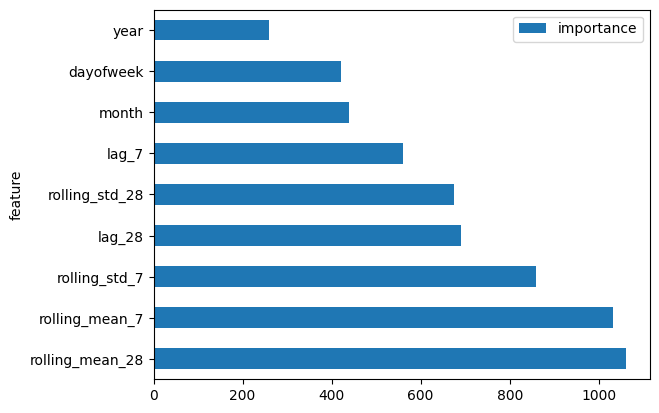

In [86]:
import matplotlib.pyplot as plt

importance.plot(
    x='feature',
    y='importance',
    kind='barh'
)

plt.show()

In [87]:
preds = model.predict(X_test)

from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

mae = mean_absolute_error(y_test, preds)
rmse = np.sqrt(mean_squared_error(y_test, preds))

print("MAE:", mae)
print("RMSE:", rmse)

MAE: 1.0057937384967275
RMSE: 2.574683048934012


In [88]:
pred_df = pd.DataFrame({
    'actual': y_test.values,
    'lgbm_pred': preds
})

pred_df.to_csv('lgbm_predictions.csv', index=False)

pred_df.head()

,actual,lgbm_pred
0,0,0.031357
1,1,0.670882
2,0,4.234147
3,0,0.157169
4,1,0.511104


In [89]:
import pandas as pd

pred_df = pd.DataFrame({
    'actual': y_test.values,
    'lgbm_pred': preds
})

pred_df.to_csv('lgbm_predictions.csv', index=False)

print("LightGBM predictions saved")

LightGBM predictions saved
